In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### import data

In [3]:
df = pd.read_csv(r"C:\Users\Anish Kumar\Downloads\large_sales.csv")

In [4]:
df.head(5)

,Order_ID,Order_Date,City,Product,Category,Channel,Customer_Segment,Payment_Method,Quantity,Unit_Price,...,Sales,Cost,Profit,Profit_Margin_Pct,Month,Month_Name,Quarter,Year,Day_Name,Weekend
0,ORD0097384,2024-01-01,Bengaluru,Tablet,Office,Store,Consumer,Debit Card,1,43384.87,...,35041.96,23400.29,11641.67,33.22,1,January,Q1,2024,Monday,No
1,ORD0054822,2024-01-01,Bengaluru,Headphones,Accessories,Marketplace,Home Office,Debit Card,7,35564.72,...,247832.75,181138.97,66693.78,26.91,1,January,Q1,2024,Monday,No
2,ORD0006567,2024-01-01,Hyderabad,Headphones,Office,Marketplace,Corporate,UPI,6,98829.18,...,529941.83,315728.84,214212.99,40.42,1,January,Q1,2024,Monday,No
3,ORD0037082,2024-01-01,Bengaluru,Monitor,Accessories,Marketplace,Consumer,UPI,4,12506.66,...,46940.00,30202.41,16737.59,35.66,1,January,Q1,2024,Monday,No
4,ORD0076597,2024-01-01,Kolkata,Mouse,Electronics,Online,Corporate,Debit Card,3,73625.86,...,168087.84,129593.53,38494.31,22.90,1,January,Q1,2024,Monday,No


In [5]:
df.tail(5)

,Order_ID,Order_Date,City,Product,Category,Channel,Customer_Segment,Payment_Method,Quantity,Unit_Price,...,Sales,Cost,Profit,Profit_Margin_Pct,Month,Month_Name,Quarter,Year,Day_Name,Weekend
99995,ORD0084825,2025-12-31,Delhi,Keyboard,Accessories,Store,Corporate,UPI,1,116767.52,...,90553.21,64568.50,25984.71,28.70,12,December,Q4,2025,Wednesday,No
99996,ORD0031111,2025-12-31,Pune,Tablet,Office,Marketplace,Consumer,Debit Card,3,112068.10,...,314519.12,238568.44,75950.68,24.15,12,December,Q4,2025,Wednesday,No
99997,ORD0067132,2025-12-31,Hyderabad,Headphones,Electronics,Store,Home Office,Credit Card,5,14379.50,...,63161.95,49297.27,13864.68,21.95,12,December,Q4,2025,Wednesday,No
99998,ORD0056816,2025-12-31,Kolkata,Printer,Accessories,Online,Home Office,Net Banking,2,54367.81,...,84879.02,53897.89,30981.13,36.50,12,December,Q4,2025,Wednesday,No
99999,ORD0023522,2025-12-31,Mumbai,Laptop,Office,Store,Consumer,Credit Card,3,3355.02,...,9774.18,8544.38,1229.80,12.58,12,December,Q4,2025,Wednesday,No


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Order_ID           100000 non-null  str    
 1   Order_Date         100000 non-null  str    
 2   City               100000 non-null  str    
 3   Product            100000 non-null  str    
 4   Category           100000 non-null  str    
 5   Channel            100000 non-null  str    
 6   Customer_Segment   100000 non-null  str    
 7   Payment_Method     99700 non-null   str    
 8   Quantity           100000 non-null  int64  
 9   Unit_Price         100000 non-null  float64
 10  Discount_Pct       99500 non-null   float64
 11  Customer_Age       100000 non-null  int64  
 12  Customer_Rating    99000 non-null   float64
 13  Gross_Sales        100000 non-null  float64
 14  Discount_Amount    100000 non-null  float64
 15  Sales              100000 non-null  float64
 16  Cost          

In [7]:
df.columns

Index(['Order_ID', 'Order_Date', 'City', 'Product', 'Category', 'Channel',
       'Customer_Segment', 'Payment_Method', 'Quantity', 'Unit_Price',
       'Discount_Pct', 'Customer_Age', 'Customer_Rating', 'Gross_Sales',
       'Discount_Amount', 'Sales', 'Cost', 'Profit', 'Profit_Margin_Pct',
       'Month', 'Month_Name', 'Quarter', 'Year', 'Day_Name', 'Weekend'],
      dtype='str')

In [8]:
df.isnull().sum()

Order_ID                0
Order_Date              0
City                    0
Product                 0
Category                0
Channel                 0
Customer_Segment        0
Payment_Method        300
Quantity                0
Unit_Price              0
Discount_Pct          500
Customer_Age            0
Customer_Rating      1000
Gross_Sales             0
Discount_Amount         0
Sales                   0
Cost                    0
Profit                  0
Profit_Margin_Pct       0
Month                   0
Month_Name              0
Quarter                 0
Year                    0
Day_Name                0
Weekend                 0
dtype: int64

### Fill The Payment_Method Value

In [9]:
df["Payment_Method"].unique()

<StringArray>
['Debit Card', 'UPI', 'Cash', 'Credit Card', 'Net Banking', nan]
Length: 6, dtype: str

In [10]:
df["Payment_Method"] = df["Payment_Method"].fillna(
    df["Payment_Method"].mode()[0]
)

### ### Fill The Discount_Pct Value

In [11]:
df["Discount_Pct"]

0        19.23
1         0.45
2        10.63
3         6.17
4        23.90
         ...  
99995    22.45
99996     6.45
99997    12.15
99998    21.94
99999     2.89
Name: Discount_Pct, Length: 100000, dtype: float64

In [12]:
df["Discount_Pct"] = df["Discount_Pct"].fillna(
    df["Discount_Pct"].median()
)

### Fill The Customer_Rating Value

In [13]:
df["Customer_Rating"]

0        1.6
1        2.6
2        1.3
3        1.9
4        2.1
        ... 
99995    2.1
99996    4.4
99997    3.4
99998    4.1
99999    2.7
Name: Customer_Rating, Length: 100000, dtype: float64

In [14]:
df["Customer_Rating"] = df["Customer_Rating"].fillna(
    df["Customer_Rating"].median()
)

In [15]:
df.isna().sum()

Order_ID             0
Order_Date           0
City                 0
Product              0
Category             0
Channel              0
Customer_Segment     0
Payment_Method       0
Quantity             0
Unit_Price           0
Discount_Pct         0
Customer_Age         0
Customer_Rating      0
Gross_Sales          0
Discount_Amount      0
Sales                0
Cost                 0
Profit               0
Profit_Margin_Pct    0
Month                0
Month_Name           0
Quarter              0
Year                 0
Day_Name             0
Weekend              0
dtype: int64

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Order_ID           100000 non-null  str    
 1   Order_Date         100000 non-null  str    
 2   City               100000 non-null  str    
 3   Product            100000 non-null  str    
 4   Category           100000 non-null  str    
 5   Channel            100000 non-null  str    
 6   Customer_Segment   100000 non-null  str    
 7   Payment_Method     100000 non-null  str    
 8   Quantity           100000 non-null  int64  
 9   Unit_Price         100000 non-null  float64
 10  Discount_Pct       100000 non-null  float64
 11  Customer_Age       100000 non-null  int64  
 12  Customer_Rating    100000 non-null  float64
 13  Gross_Sales        100000 non-null  float64
 14  Discount_Amount    100000 non-null  float64
 15  Sales              100000 non-null  float64
 16  Cost          

In [26]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype        
---  ------             --------------   -----        
 0   Order_ID           100000 non-null  str          
 1   Order_Date         100000 non-null  datetime64[s]
 2   City               100000 non-null  str          
 3   Product            100000 non-null  str          
 4   Category           100000 non-null  str          
 5   Channel            100000 non-null  str          
 6   Customer_Segment   100000 non-null  str          
 7   Payment_Method     100000 non-null  str          
 8   Quantity           100000 non-null  int64        
 9   Unit_Price         100000 non-null  float64      
 10  Discount_Pct       100000 non-null  float64      
 11  Customer_Age       100000 non-null  int64        
 12  Customer_Rating    100000 non-null  float64      
 13  Gross_Sales        100000 non-null  float64      
 14  Discount_Amount 

## Bar Chart 

1. Calculate the total Sales for each City and create a bar chart.

In [45]:
Total_Sales = df.groupby("City")["Sales"].sum().round(2)
Total_Sales

City
Bengaluru    2.577070e+09
Chennai      2.657385e+09
Delhi        2.549211e+09
Hyderabad    2.539507e+09
Jaipur       2.547586e+09
Kolkata      2.557086e+09
Mumbai       2.590720e+09
Pune         2.564498e+09
Name: Sales, dtype: float64

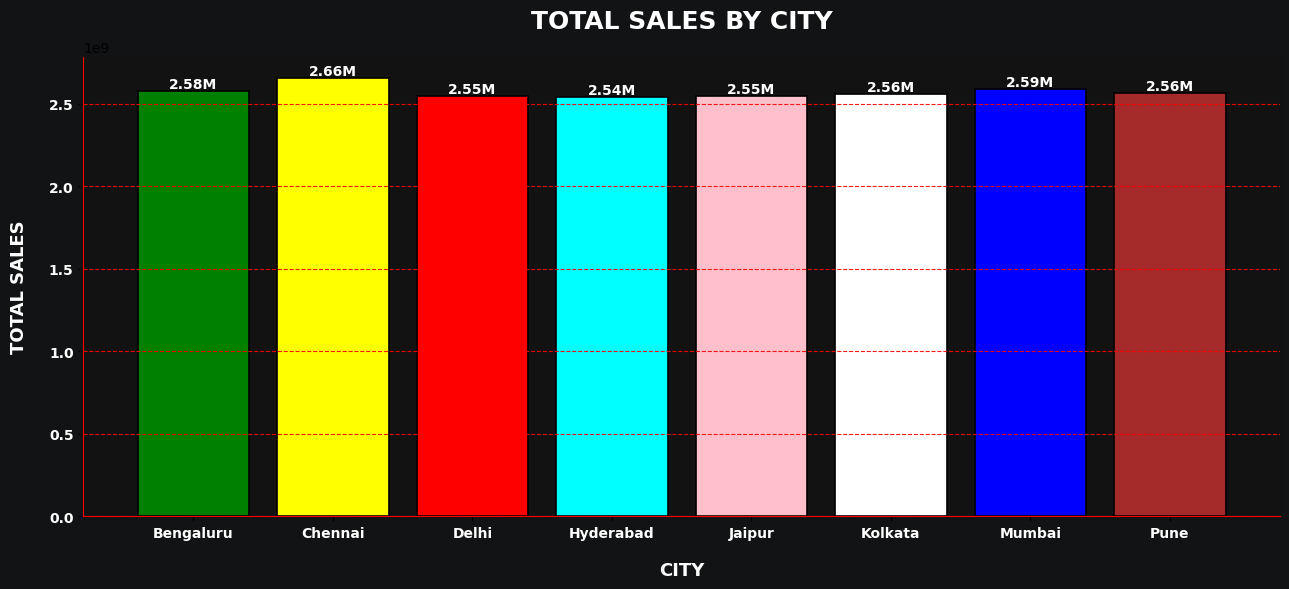

In [100]:
plt.figure(figsize=(13, 6), facecolor="#121314", dpi=100)

bars = plt.bar(
    Total_Sales.index,
    Total_Sales.values,
    edgecolor="black",
    color=["green", "Yellow", "red", "cyan", "pink", "white", "blue", "brown"],
    linewidth=1.2
)

plt.title(
    "TOTAL SALES BY CITY",
    pad=20,
    color="white",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "CITY",
    color="white",
    fontsize=13,
    fontweight="bold",
    labelpad=15
)

plt.ylabel(
    "TOTAL SALES", 
    color="White",
    fontsize=13,
    fontweight="bold",
    labelpad=15
)

plt.xticks(
    color="white",
    fontsize=10,
    fontweight="bold",
)

plt.yticks(
    color="white",
    fontsize=10,
    fontweight="bold",
)

for bar in bars:
    values = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        values + 1,
        f"{values / 1e9:.2f}M",
        fontsize=10,
        ha="center",
        va="bottom",
        fontweight="bold",
        color="white"
    )
    
plt.gca().set_facecolor("#121212")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.9,
    color="red"
)

plt.tight_layout()

plt.gca().spines["top"].set_color("#121212")
plt.gca().spines["bottom"].set_color("red")
plt.gca().spines["left"].set_color("red")
plt.gca().spines["right"].set_color("#121212")

plt.show()

In [42]:
df

,Order_ID,Order_Date,City,Product,Category,Channel,Customer_Segment,Payment_Method,Quantity,Unit_Price,...,Sales,Cost,Profit,Profit_Margin_Pct,Month,Month_Name,Quarter,Year,Day_Name,Weekend
0,ORD0097384,2024-01-01,Bengaluru,Tablet,Office,Store,Consumer,Debit Card,1,43384.87,...,35041.96,23400.29,11641.67,33.22,1,January,Q1,2024,Monday,No
1,ORD0054822,2024-01-01,Bengaluru,Headphones,Accessories,Marketplace,Home Office,Debit Card,7,35564.72,...,247832.75,181138.97,66693.78,26.91,1,January,Q1,2024,Monday,No
2,ORD0006567,2024-01-01,Hyderabad,Headphones,Office,Marketplace,Corporate,UPI,6,98829.18,...,529941.83,315728.84,214212.99,40.42,1,January,Q1,2024,Monday,No
3,ORD0037082,2024-01-01,Bengaluru,Monitor,Accessories,Marketplace,Consumer,UPI,4,12506.66,...,46940.00,30202.41,16737.59,35.66,1,January,Q1,2024,Monday,No
4,ORD0076597,2024-01-01,Kolkata,Mouse,Electronics,Online,Corporate,Debit Card,3,73625.86,...,168087.84,129593.53,38494.31,22.90,1,January,Q1,2024,Monday,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD0084825,2025-12-31,Delhi,Keyboard,Accessories,Store,Corporate,UPI,1,116767.52,...,90553.21,64568.50,25984.71,28.70,12,December,Q4,2025,Wednesday,No
99996,ORD0031111,2025-12-31,Pune,Tablet,Office,Marketplace,Consumer,Debit Card,3,112068.10,...,314519.12,238568.44,75950.68,24.15,12,December,Q4,2025,Wednesday,No
99997,ORD0067132,2025-12-31,Hyderabad,Headphones,Electronics,Store,Home Office,Credit Card,5,14379.50,...,63161.95,49297.27,13864.68,21.95,12,December,Q4,2025,Wednesday,No
99998,ORD0056816,2025-12-31,Kolkata,Printer,Accessories,Online,Home Office,Net Banking,2,54367.81,...,84879.02,53897.89,30981.13,36.50,12,December,Q4,2025,Wednesday,No


2. Calculate the total Profit for each Category and create a bar chart.

3. Calculate the average Customer Rating for each City.

4. Calculate the total Quantity sold for each Product.

5. Calculate the average Profit Margin (%) for each Customer Segment.

2. Horizontal Bar — Q6–Q10
Create a horizontal bar chart showing total Sales by City.
Show the top 10 Products by total Profit.
Show the top 10 Cities by total Quantity sold.
Show the average Sales by Customer Segment.
Show the total Profit by Payment Method, sorted from highest to lowest.

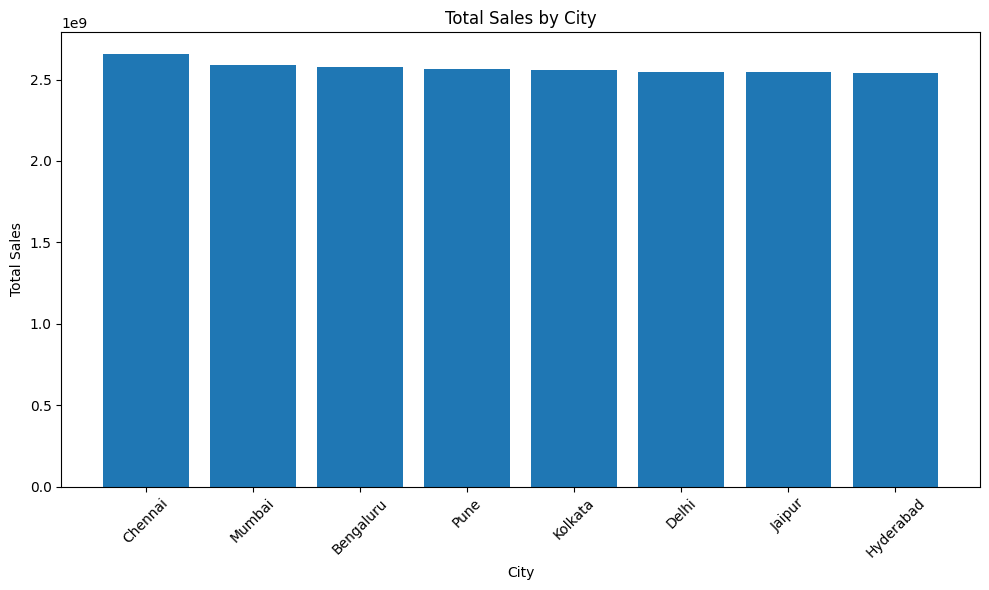

In [ ]:
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(
    city_sales.index,
    city_sales.values
)

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

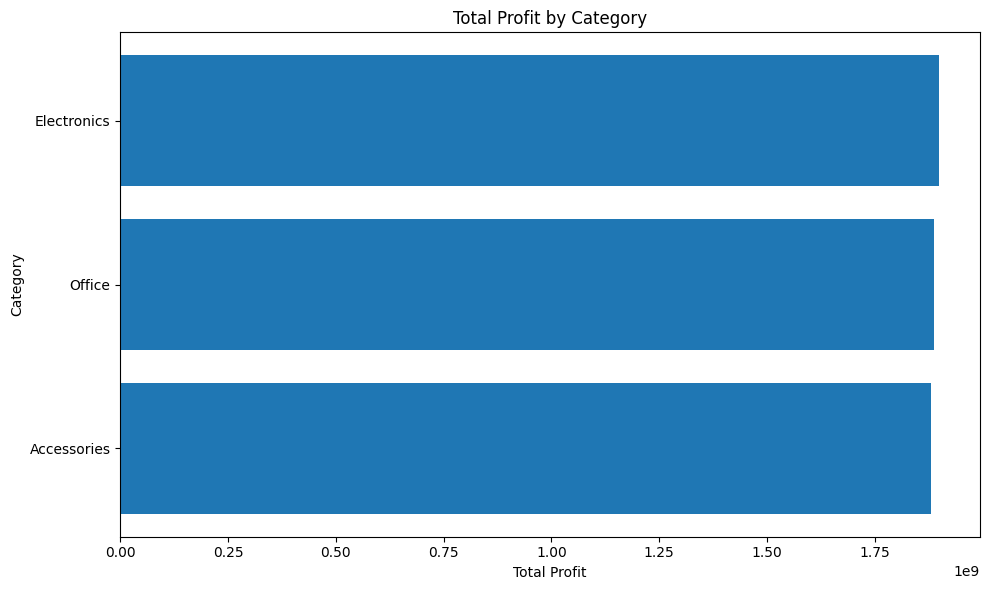

In [ ]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    category_profit.index,
    category_profit.values
)

plt.title("Total Profit by Category")
plt.xlabel("Total Profit")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

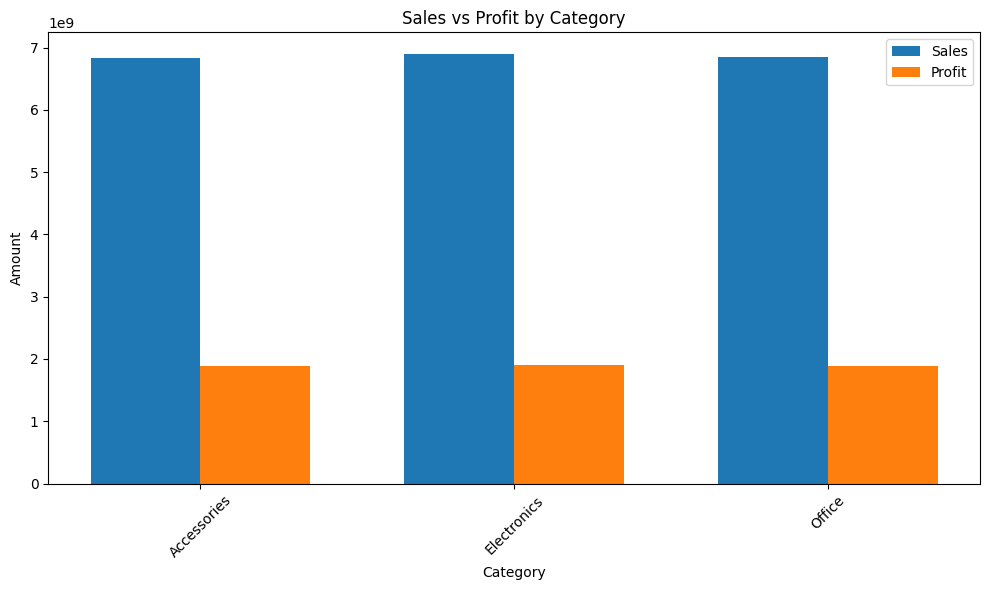

In [ ]:
data = df.groupby("Category")[["Sales", "Profit"]].sum()

x = np.arange(len(data))

width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    data["Sales"],
    width,
    label="Sales"
)

plt.bar(
    x + width / 2,
    data["Profit"],
    width,
    label="Profit"
)

plt.xticks(
    x,
    data.index,
    rotation=45
)

plt.title("Sales vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")

plt.legend()

plt.tight_layout()
plt.show()

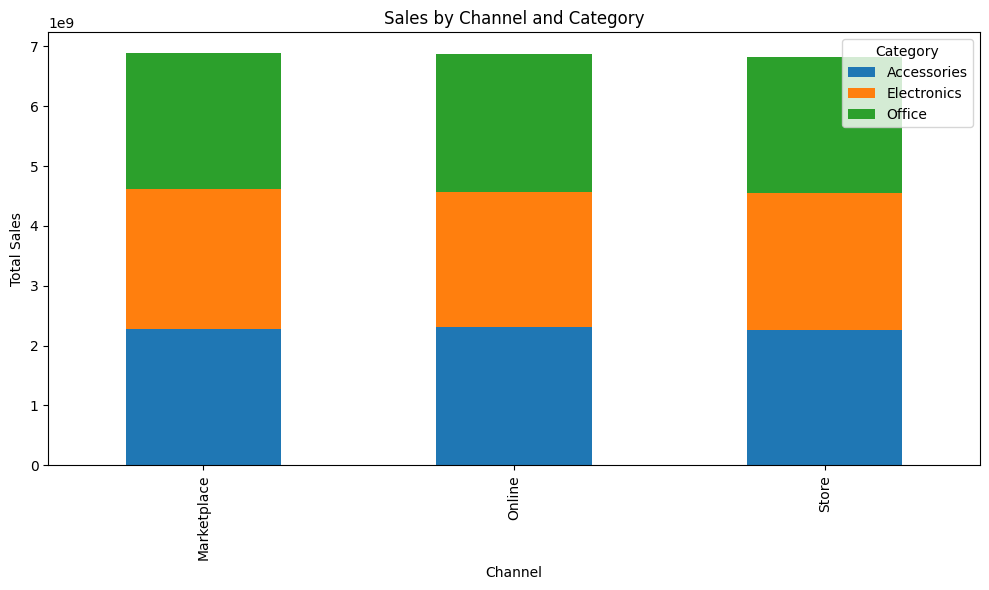

In [ ]:
data = pd.pivot_table(
    df,
    values="Sales",
    index="Channel",
    columns="Category",
    aggfunc="sum",
    fill_value=0
)

data.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Sales by Channel and Category")
plt.xlabel("Channel")
plt.ylabel("Total Sales")

plt.legend(title="Category")

plt.tight_layout()
plt.show()

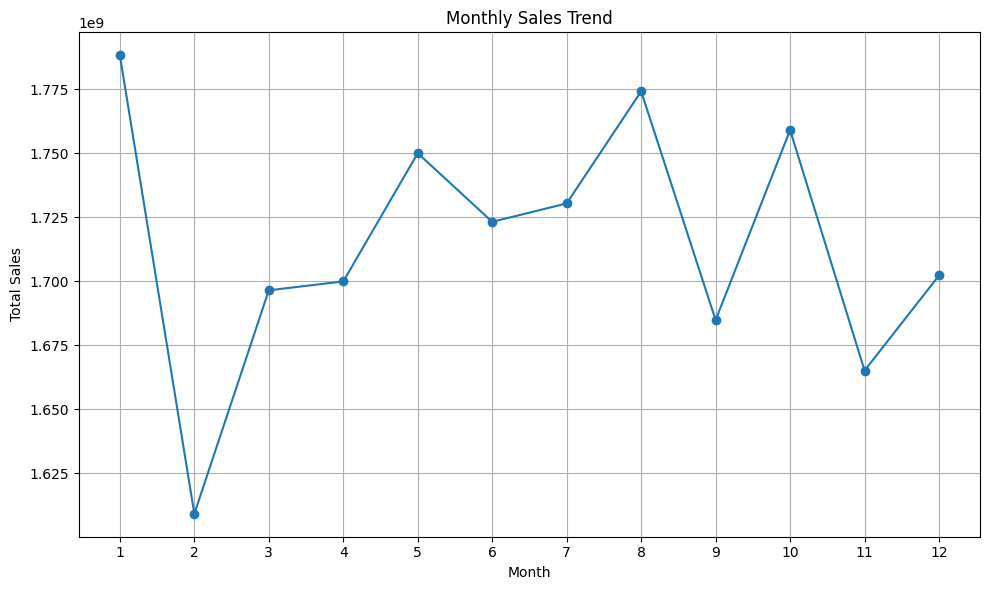

In [ ]:
monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
      .sort_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(range(1, 13))
plt.grid(True)

plt.tight_layout()
plt.show()

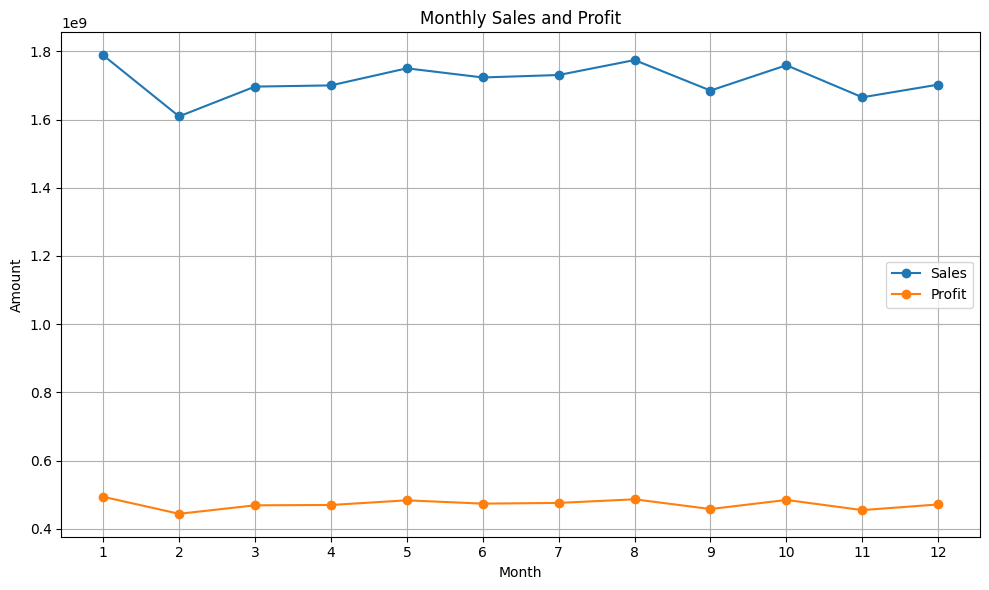

In [ ]:
monthly_data = (
    df.groupby("Month")[["Sales", "Profit"]]
      .sum()
      .sort_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_data.index,
    monthly_data["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    monthly_data.index,
    monthly_data["Profit"],
    marker="o",
    label="Profit"
)

plt.title("Monthly Sales and Profit")
plt.xlabel("Month")
plt.ylabel("Amount")

plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

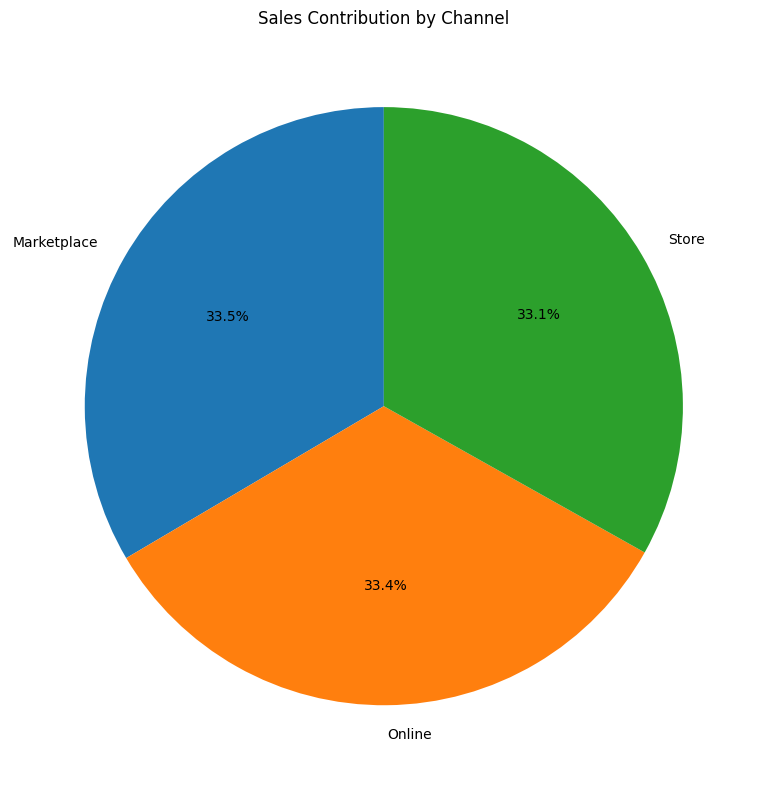

In [ ]:
channel_sales = df.groupby("Channel")["Sales"].sum()

plt.figure(figsize=(8, 8))

plt.pie(
    channel_sales.values,
    labels=channel_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Contribution by Channel")

plt.tight_layout()
plt.show()

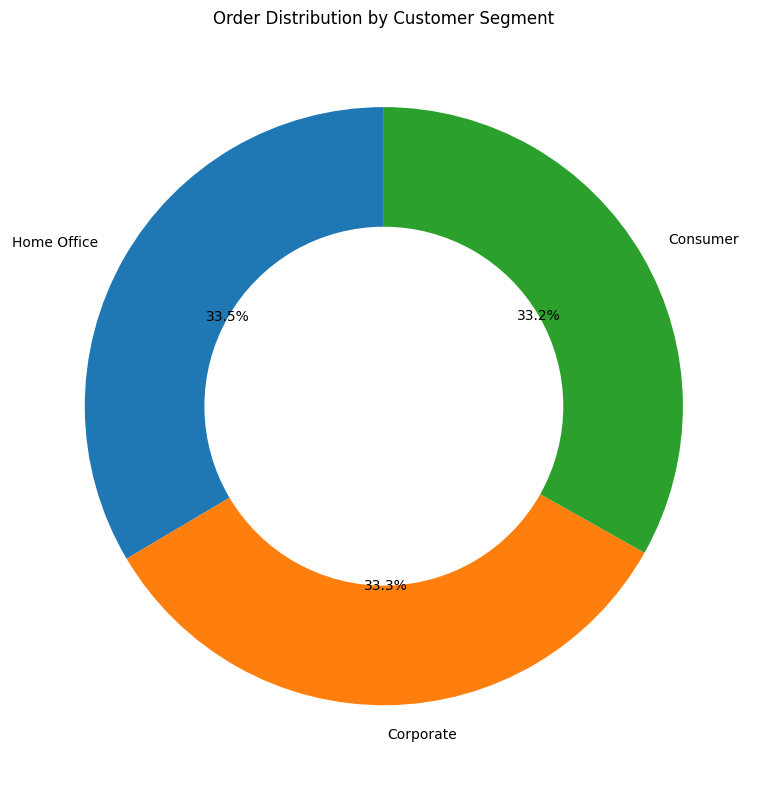

In [ ]:
segment_orders = df["Customer_Segment"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    segment_orders.values,
    labels=segment_orders.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("Order Distribution by Customer Segment")

plt.tight_layout()
plt.show()

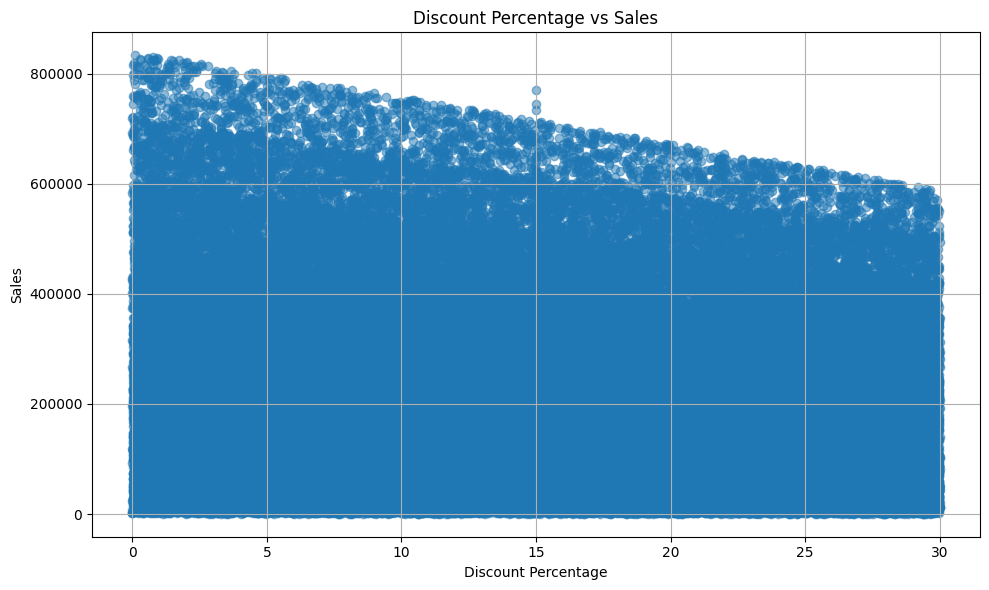

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount_Pct"],
    df["Sales"],
    alpha=0.5
)

plt.title("Discount Percentage vs Sales")
plt.xlabel("Discount Percentage")
plt.ylabel("Sales")

plt.grid(True)

plt.tight_layout()
plt.show()

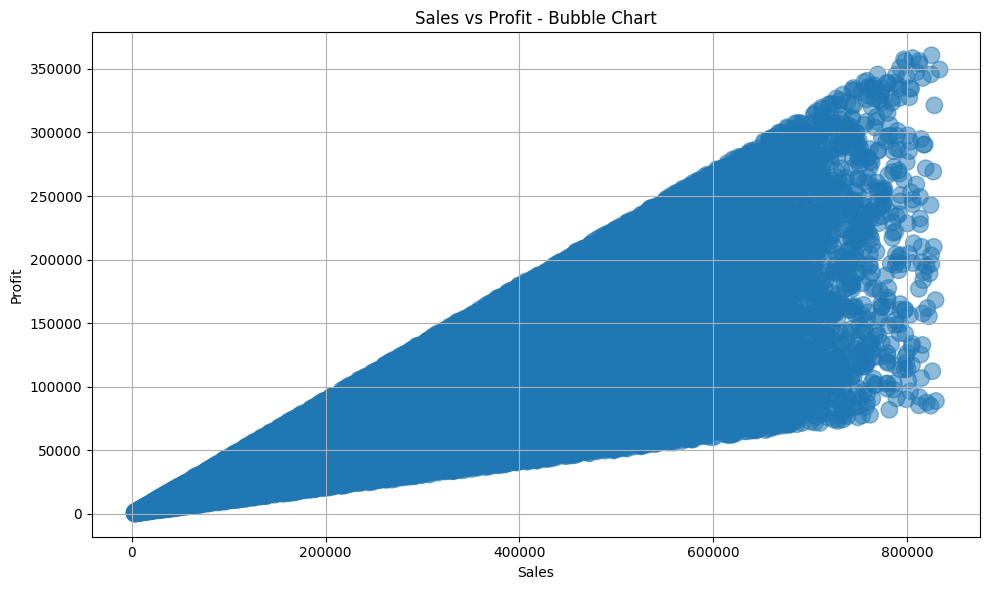

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Sales"],
    df["Profit"],
    s=df["Quantity"] * 20,
    alpha=0.5
)

plt.title("Sales vs Profit - Bubble Chart")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.grid(True)

plt.tight_layout()
plt.show()

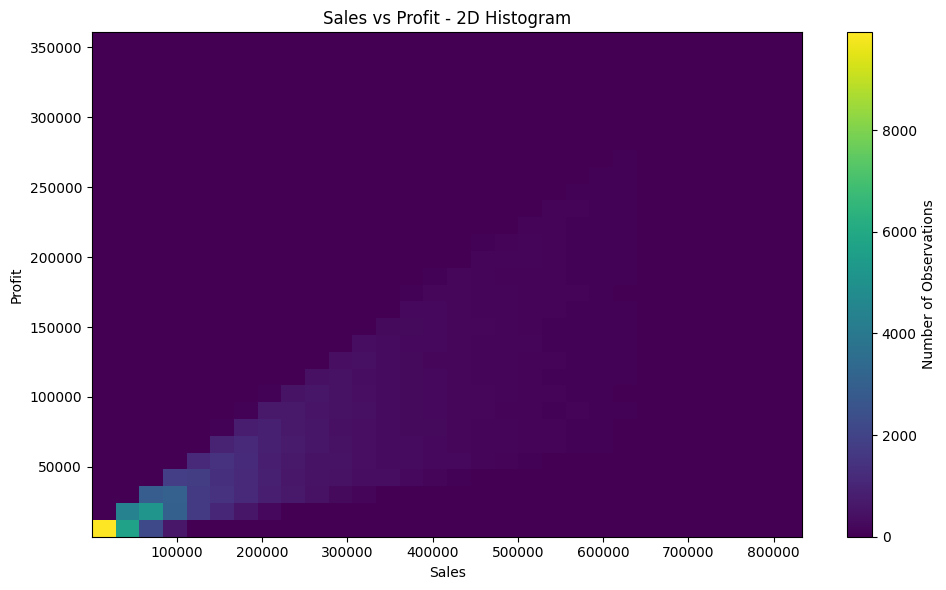

In [ ]:
plt.figure(figsize=(10, 6))

hist = plt.hist2d(
    df["Sales"],
    df["Profit"],
    bins=30
)

plt.colorbar(
    hist[3],
    label="Number of Observations"
)

plt.title("Sales vs Profit - 2D Histogram")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

C:\Users\Anish Kumar\AppData\Local\Temp\ipykernel_2180\3436542191.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


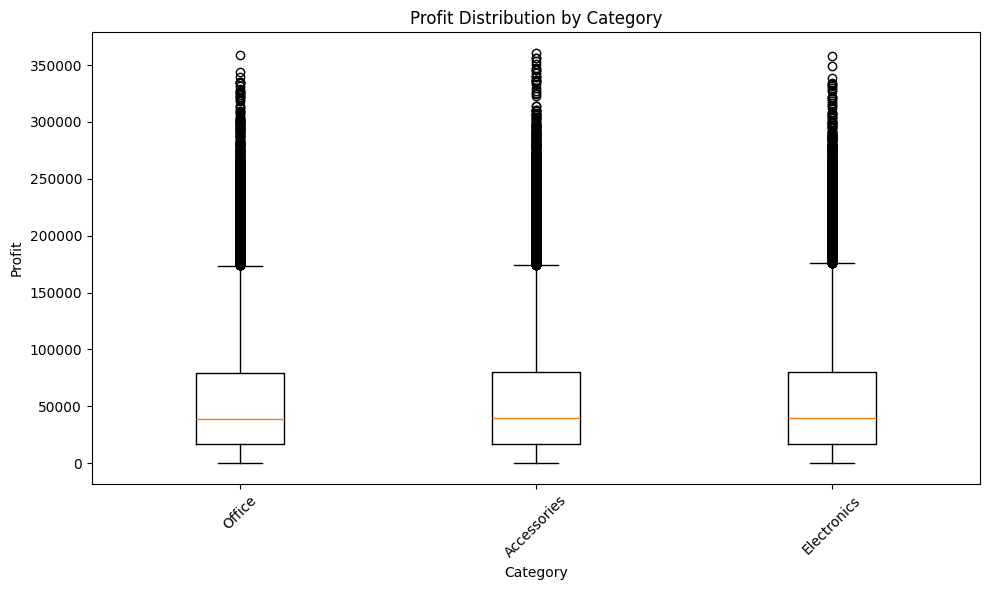

In [ ]:
categories = df["Category"].dropna().unique()

profit_data = [
    df.loc[
        df["Category"] == category,
        "Profit"
    ].dropna()
    for category in categories
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    profit_data,
    labels=categories
)

plt.title("Profit Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

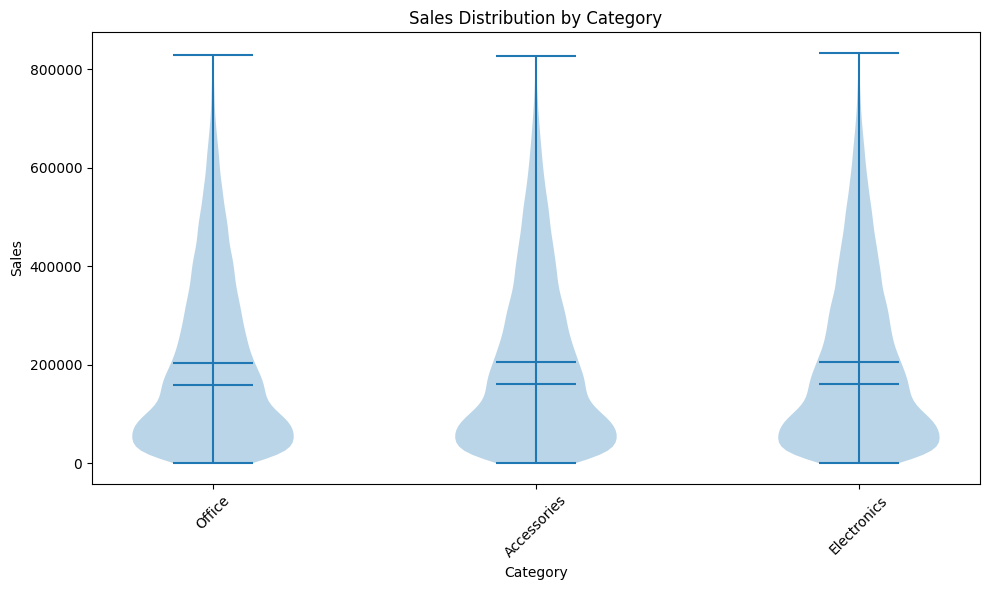

In [ ]:
categories = df["Category"].dropna().unique()

sales_data = [
    df.loc[
        df["Category"] == category,
        "Sales"
    ].dropna()
    for category in categories
]

plt.figure(figsize=(10, 6))

plt.violinplot(
    sales_data,
    showmeans=True,
    showmedians=True
)

plt.xticks(
    range(1, len(categories) + 1),
    categories,
    rotation=45
)

plt.title("Sales Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

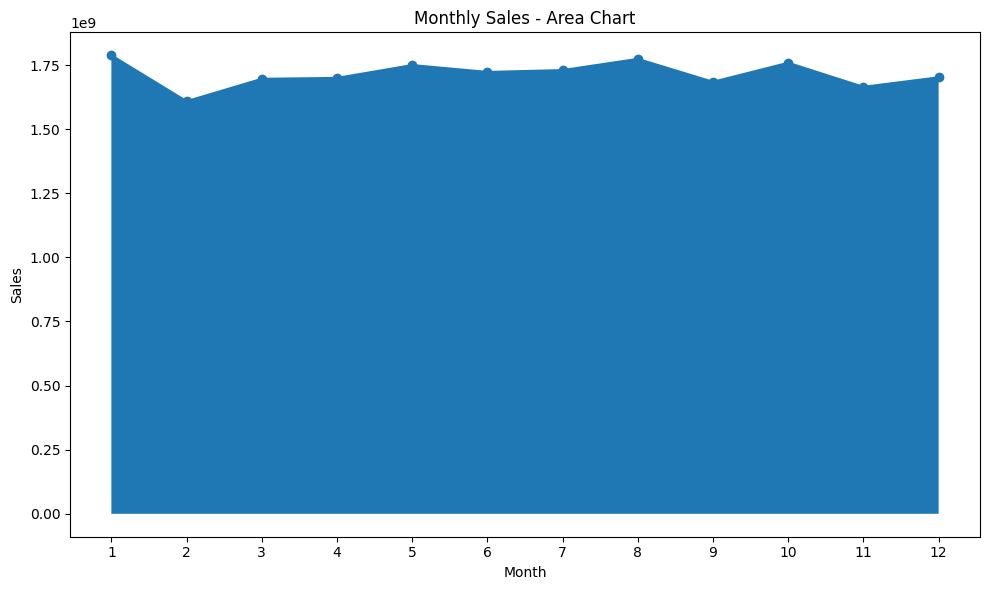

In [ ]:
monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
      .sort_index()
)

plt.figure(figsize=(10, 6))

plt.fill_between(
    monthly_sales.index,
    monthly_sales.values
)

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales - Area Chart")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

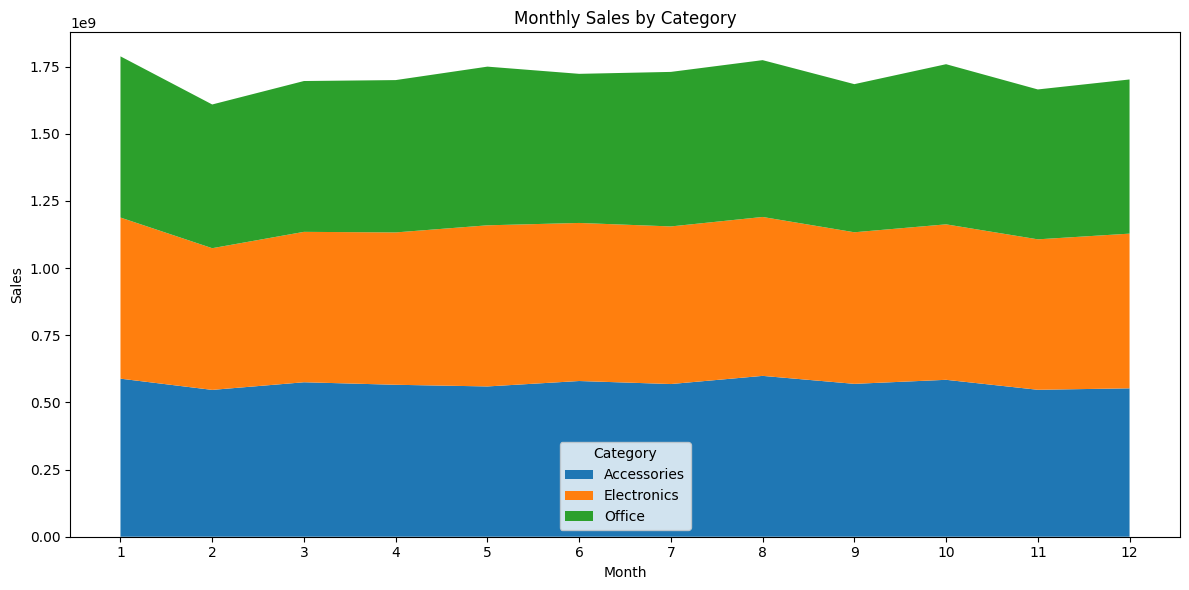

In [ ]:
data = pd.pivot_table(
    df,
    values="Sales",
    index="Month",
    columns="Category",
    aggfunc="sum",
    fill_value=0
).sort_index()

plt.figure(figsize=(12, 6))

plt.stackplot(
    data.index,
    *[data[column] for column in data.columns],
    labels=data.columns
)

plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(range(1, 13))
plt.legend(title="Category")

plt.tight_layout()
plt.show()

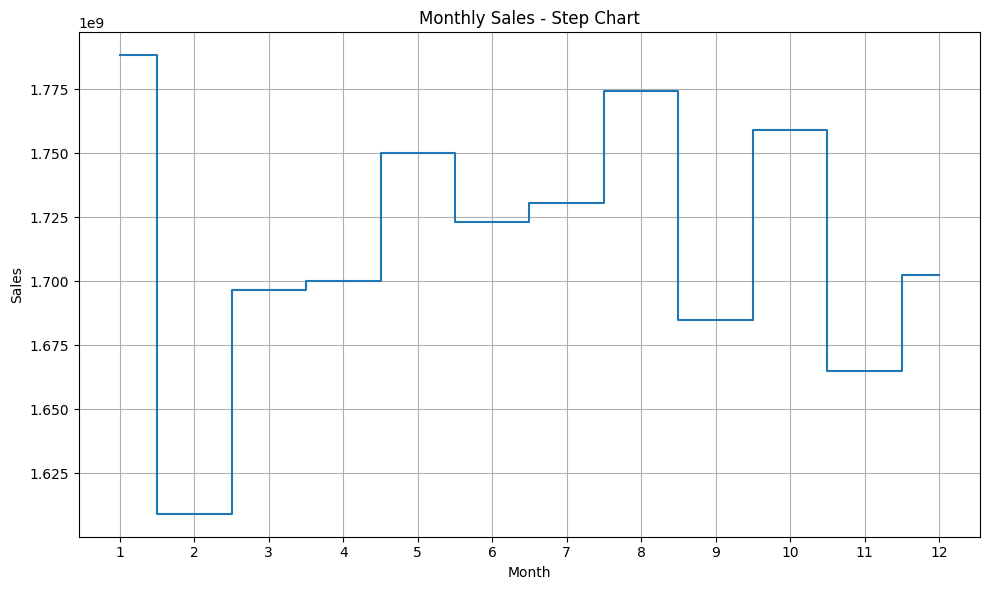

In [ ]:
monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
      .sort_index()
)

plt.figure(figsize=(10, 6))

plt.step(
    monthly_sales.index,
    monthly_sales.values,
    where="mid"
)

plt.title("Monthly Sales - Step Chart")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(range(1, 13))
plt.grid(True)

plt.tight_layout()
plt.show()

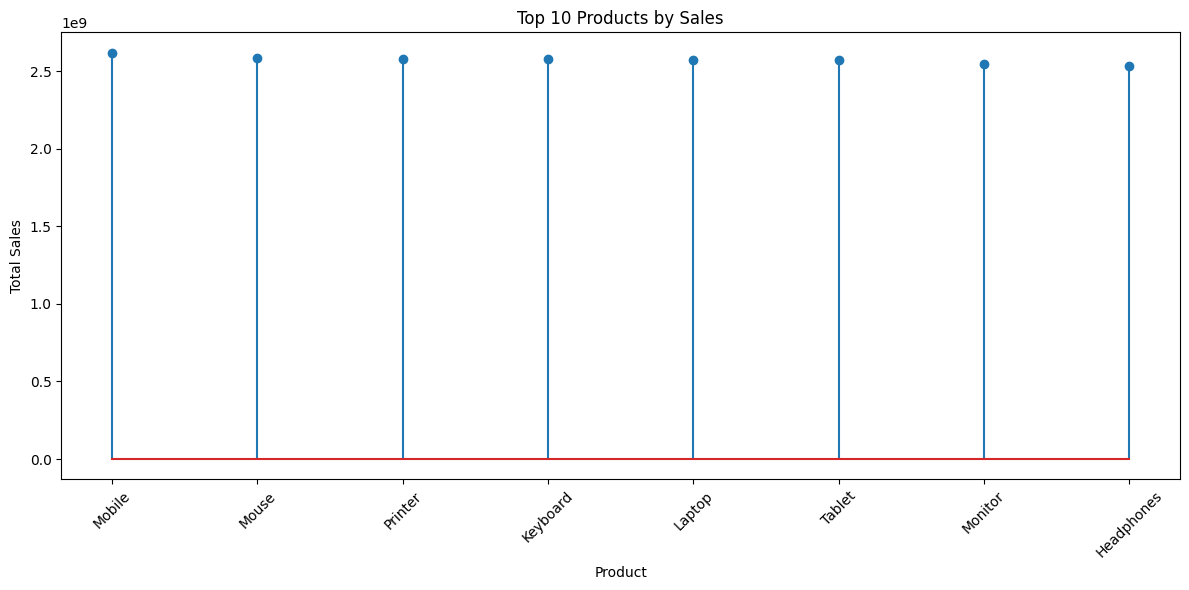

In [ ]:
product_sales = (
    df.groupby("Product")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 6))

plt.stem(
    product_sales.index,
    product_sales.values
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

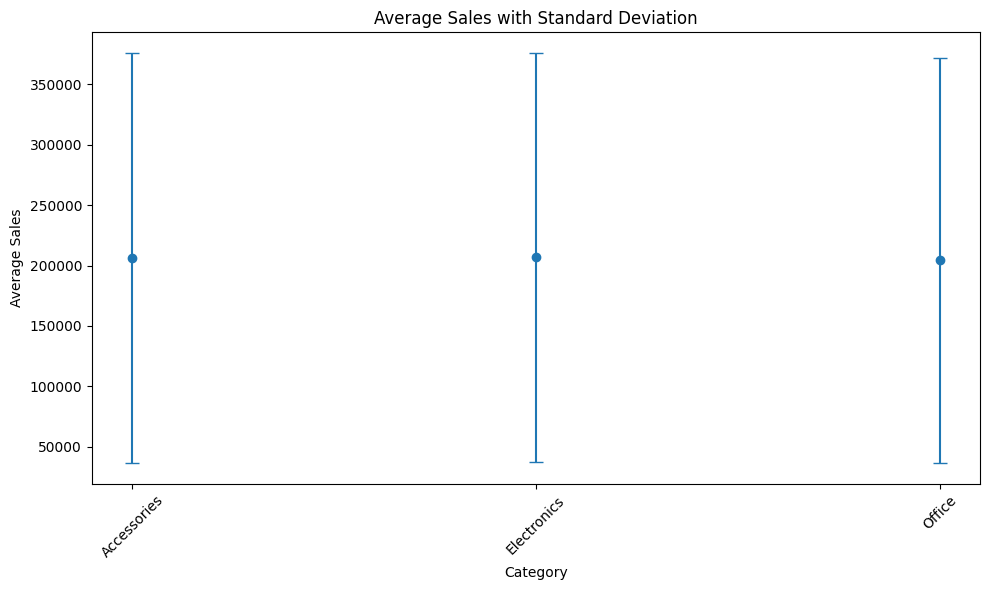

In [ ]:
data = (
    df.groupby("Category")["Sales"]
      .agg(["mean", "std"])
)

plt.figure(figsize=(10, 6))

plt.errorbar(
    data.index,
    data["mean"],
    yerr=data["std"],
    fmt="o",
    capsize=5
)

plt.title("Average Sales with Standard Deviation")
plt.xlabel("Category")
plt.ylabel("Average Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

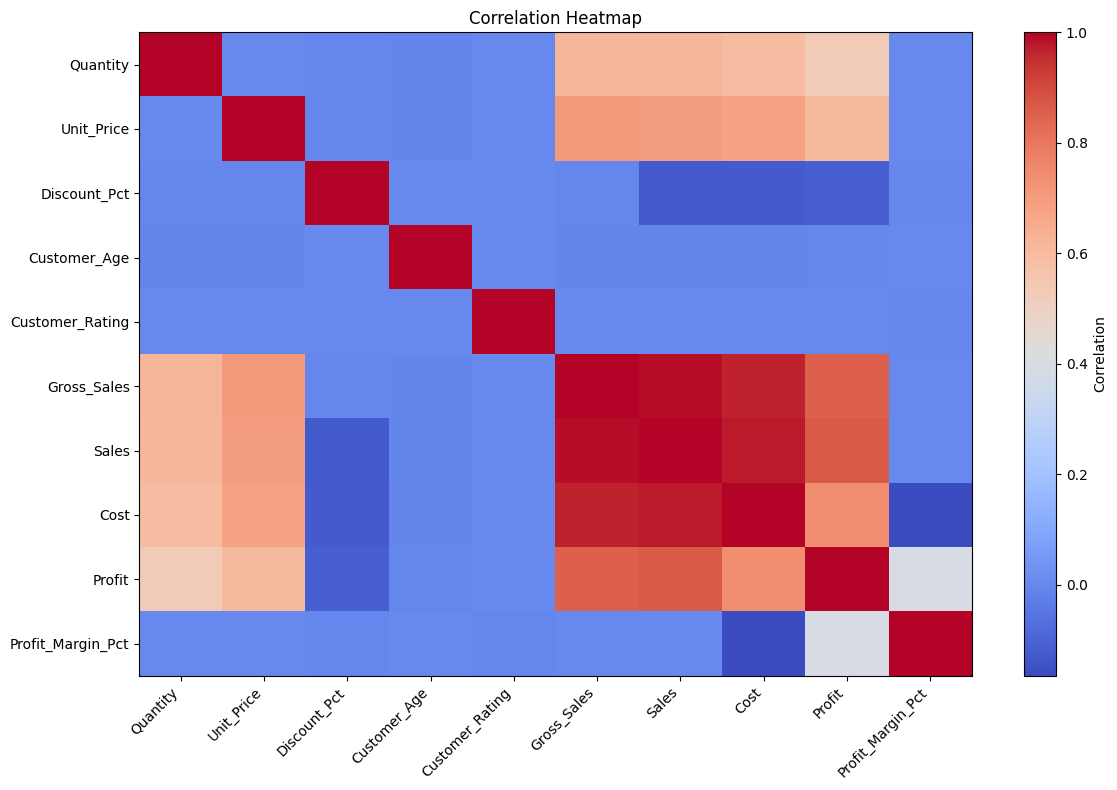

In [ ]:
numeric_columns = [
    "Quantity",
    "Unit_Price",
    "Discount_Pct",
    "Customer_Age",
    "Customer_Rating",
    "Gross_Sales",
    "Sales",
    "Cost",
    "Profit",
    "Profit_Margin_Pct"
]

corr = df[numeric_columns].corr()

plt.figure(figsize=(12, 8))

plt.imshow(
    corr,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

hexbin = plt.hexbin(
    df["Sales"],
    df["Profit"],
    gridsize=30,
    mincnt=1
)

plt.colorbar(
    hexbin,
    label="Number of Observations"
)

plt.title("Sales vs Profit - Hexbin Plot")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

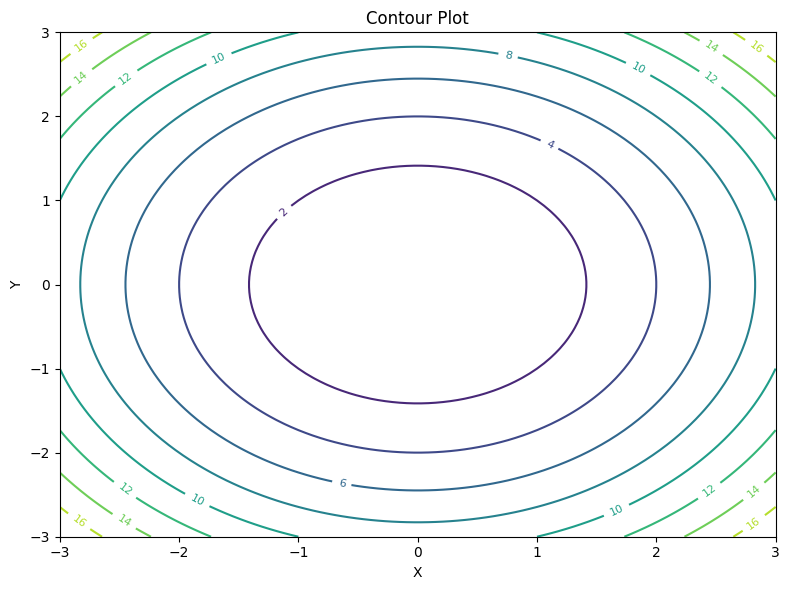

In [ ]:
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)

X, Y = np.meshgrid(x, y)

Z = X**2 + Y**2

plt.figure(figsize=(8, 6))

contour = plt.contour(
    X,
    Y,
    Z,
    levels=10
)

plt.clabel(
    contour,
    inline=True,
    fontsize=8
)

plt.title("Contour Plot")
plt.xlabel("X")
plt.ylabel("Y")

plt.tight_layout()
plt.show()

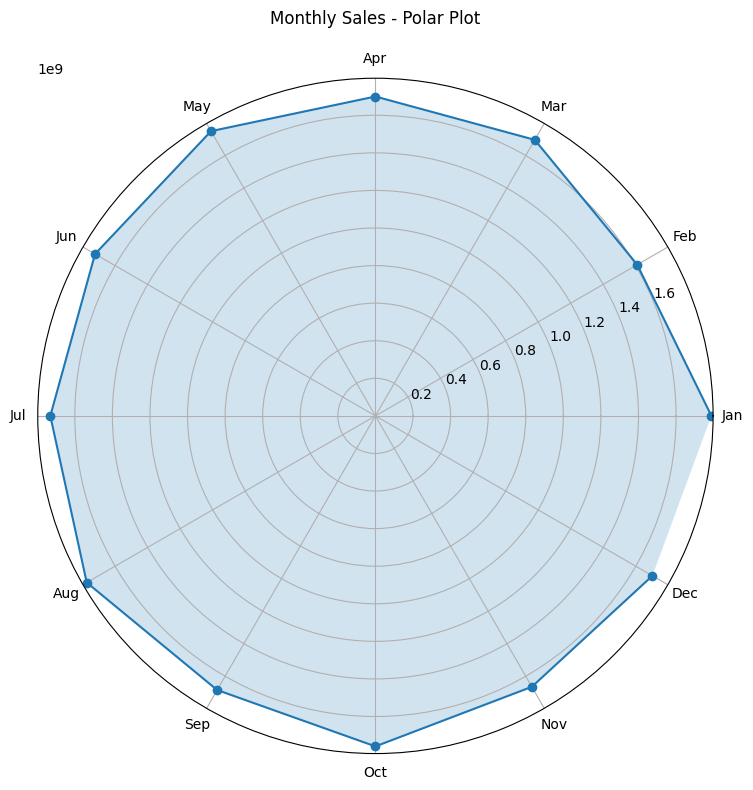

In [ ]:
monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
      .reindex(range(1, 13))
)

angles = np.linspace(
    0,
    2 * np.pi,
    12,
    endpoint=False
)

values = monthly_sales.values

plt.figure(figsize=(8, 8))

ax = plt.subplot(
    111,
    projection="polar"
)

ax.plot(
    angles,
    values,
    marker="o"
)

ax.fill(
    angles,
    values,
    alpha=0.2
)

ax.set_title(
    "Monthly Sales - Polar Plot",
    pad=20
)

ax.set_xticks(angles)

ax.set_xticklabels([
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
])

plt.tight_layout()
plt.show()

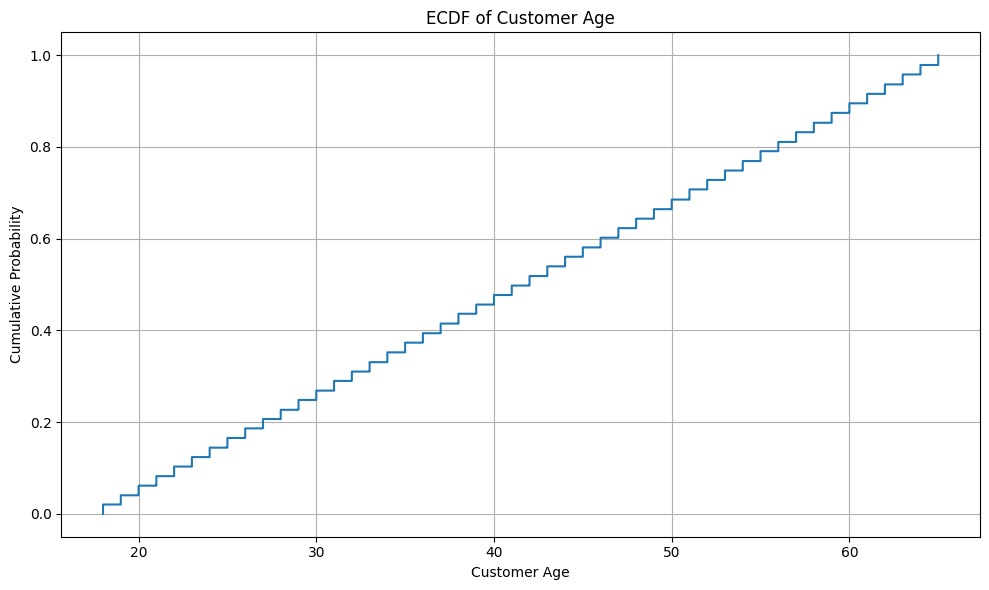

In [ ]:
age = (
    df["Customer_Age"]
    .dropna()
    .sort_values()
    .values
)

n = len(age)

y = np.arange(
    1,
    n + 1
) / n

plt.figure(figsize=(10, 6))

plt.step(
    age,
    y,
    where="post"
)

plt.title("ECDF of Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Cumulative Probability")

plt.grid(True)

plt.tight_layout()
plt.show()

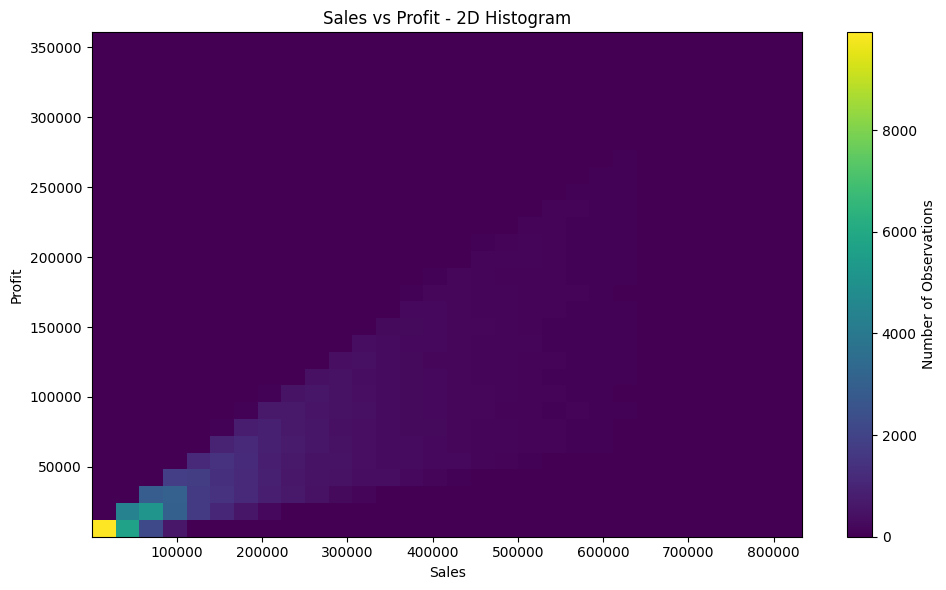

In [ ]:
plt.figure(figsize=(10, 6))

hist = plt.hist2d(
    df["Sales"],
    df["Profit"],
    bins=30
)

plt.colorbar(
    hist[3],
    label="Number of Observations"
)

plt.title("Sales vs Profit - 2D Histogram")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

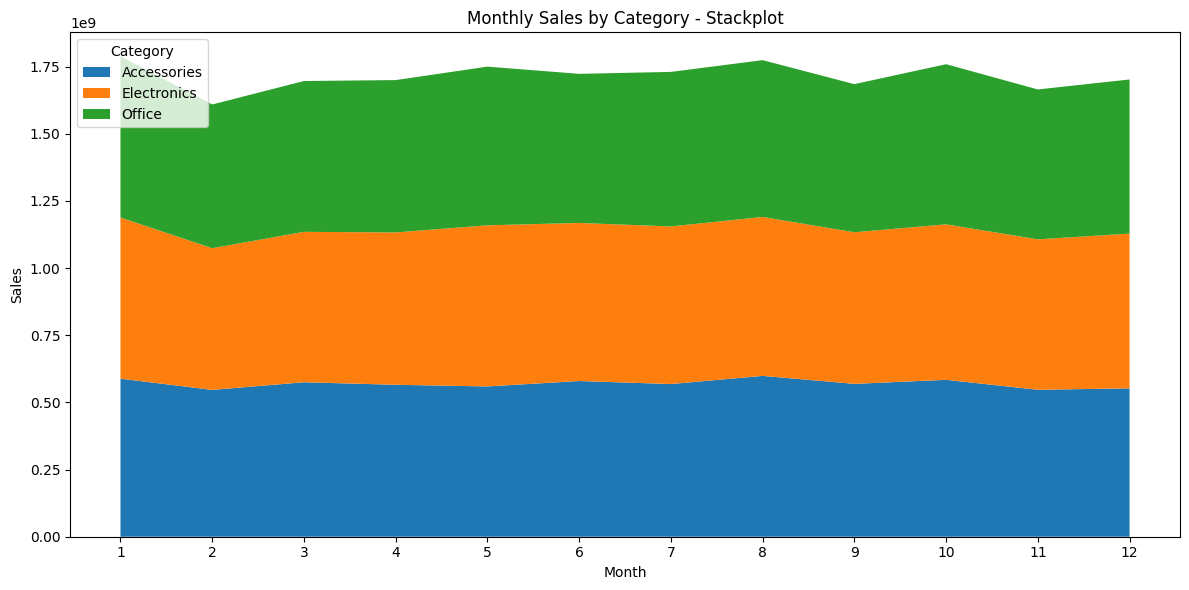

In [ ]:
data = pd.pivot_table(
    df,
    values="Sales",
    index="Month",
    columns="Category",
    aggfunc="sum",
    fill_value=0
).sort_index()

plt.figure(figsize=(12, 6))

plt.stackplot(
    data.index,
    *[data[column] for column in data.columns],
    labels=data.columns
)

plt.title("Monthly Sales by Category - Stackplot")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(range(1, 13))

plt.legend(
    title="Category",
    loc="upper left"
)

plt.tight_layout()
plt.show()

3. Grouped Bar — Q11–Q15
Compare total Sales across Cities for each Channel.
Compare total Profit across Categories for each Customer Segment.
Compare average Customer Rating across Cities for Store vs Marketplace.
Compare total Quantity sold across Categories for each Channel.
Compare average Discount (%) across Cities for each Customer Segment.
4. Stacked Bar — Q16–Q20
Show total Sales by City and Channel using a stacked bar chart.
Show total Profit by Category and Customer Segment.
Show order count by City and Payment Method.
Show total Quantity by Category and Channel.
Show order count by City and Weekend status.
5. Line Chart — Q21–Q25
Plot monthly total Sales.
Plot monthly total Profit.
Plot monthly total Quantity sold.
Plot monthly average Customer Rating.
Plot monthly average Discount (%).
6. Multiple Line — Q26–Q30
Plot monthly Sales for each City.
Plot monthly Profit for each Category.
Compare monthly Sales for Store and Marketplace.
Plot monthly Quantity sold for each Channel.
Compare monthly Sales and Profit on the same chart.
7. Pie Chart — Q31–Q35
Show the percentage distribution of orders by City.
Show the percentage distribution of Sales by Category.
Show the percentage distribution of orders by Channel.
Show the percentage distribution of orders by Customer Segment.
Show the percentage distribution of orders by Payment Method.
8. Donut Chart — Q36–Q40
Create a donut chart showing Sales contribution by City.
Show Profit contribution by Category.
Show order distribution by Channel.
Show order distribution by Customer Segment.
Show Sales contribution by Payment Method.
9. Scatter Plot — Q41–Q45
Plot Quantity vs Sales.
Plot Discount (%) vs Profit.
Plot Unit Price vs Sales.
Plot Customer Rating vs Sales.
Plot Customer Age vs Sales.
10. Bubble Chart — Q46–Q50
Plot Quantity vs Sales, with bubble size based on Profit.
Plot Discount (%) vs Profit, with bubble size based on Sales.
Plot Unit Price vs Sales, with bubble size based on Quantity.
Plot Customer Age vs Sales, with bubble size based on Customer Rating.
Plot Sales vs Profit, with bubble size based on Quantity.
11. Histogram — Q51–Q55
Plot the distribution of Sales.
Plot the distribution of Profit.
Plot the distribution of Quantity.
Plot the distribution of Customer Age.
Plot the distribution of Customer Rating.
12. Box Plot — Q56–Q60
Create a box plot of Sales by City.
Create a box plot of Profit by Category.
Create a box plot of Sales by Channel.
Create a box plot of Customer Rating by Customer Segment.
Create a box plot of Discount (%) by Category.
13. Violin Plot — Q61–Q65
Show the distribution of Sales across Cities.
Show the distribution of Profit across Categories.
Show the distribution of Sales across Channels.
Show the distribution of Customer Rating across Customer Segments.
Show the distribution of Discount (%) across Categories.
14. Area Chart — Q66–Q70
Plot monthly total Sales using an area chart.
Plot monthly total Profit.
Plot monthly total Quantity sold.
Plot monthly total Cost.
Plot monthly total Discount Amount.
15. Stacked Area — Q71–Q75
Show monthly Sales by City using a stacked area chart.
Show monthly Profit by Category.
Show monthly Sales by Channel.
Show monthly Quantity by Customer Segment.
Show monthly Sales by Payment Method.
16. Step Chart — Q76–Q80
Plot monthly Sales using a step chart.
Plot monthly Profit using a step chart.
Plot monthly Quantity sold.
Plot monthly average Customer Rating.
Plot monthly average Discount (%).
17. Stem Plot — Q81–Q85
Create a stem plot of monthly total Sales.
Create a stem plot of monthly total Profit.
Create a stem plot of monthly Quantity sold.
Create a stem plot of monthly average Customer Rating.
Create a stem plot of monthly average Discount (%).
18. Error Bar — Q86–Q90
Plot average Sales by City with standard deviation as error bars.
Plot average Profit by Category with standard deviation.
Plot average Customer Rating by City with standard deviation.
Plot average Sales by Channel with standard deviation.
Plot average Profit by Customer Segment with standard deviation.
19. Heatmap — Q91–Q95
Create a correlation heatmap of numerical columns.
Create a heatmap showing average Sales by City and Month.
Create a heatmap showing average Profit by Category and Month.
Create a heatmap showing average Sales by City and Channel.
Create a heatmap showing average Customer Rating by City and Customer Segment.
20. Hexbin Plot — Q96–Q100
Create a hexbin plot of Quantity vs Sales.
Create a hexbin plot of Discount (%) vs Profit.
Create a hexbin plot of Unit Price vs Sales.
Create a hexbin plot of Customer Age vs Sales.
Create a hexbin plot of Sales vs Profit.
21. Contour Plot — Q101–Q105
Create a contour plot showing the relationship between Discount (%) and Profit.
Create a contour plot for Quantity and Sales.
Create a contour plot for Unit Price and Sales.
Create a contour plot for Customer Age and Sales.
Create a contour plot for Sales and Profit.

⚠️ Contour plot raw categorical data ke liye nahi hota. Iske liye pehle suitable numeric grid/interpolation banana padega.

22. Polar Plot — Q106–Q110
Create a polar plot showing monthly Sales.
Create a polar plot showing monthly Profit.
Create a polar plot showing monthly Quantity sold.
Create a polar plot showing monthly average Customer Rating.
Create a polar plot showing monthly average Discount (%).
23. ECDF Plot — Q111–Q115
Create an ECDF plot for Sales.
Create an ECDF plot for Profit.
Create an ECDF plot for Quantity.
Create an ECDF plot for Customer Age.
Create an ECDF plot for Customer Rating.
24. 2D Histogram — Q116–Q120
Create a 2D histogram of Quantity vs Sales.
Create a 2D histogram of Discount (%) vs Profit.
Create a 2D histogram of Unit Price vs Sales.
Create a 2D histogram of Customer Age vs Sales.
Create a 2D histogram of Sales vs Profit.
25. Stackplot — Q121–Q125
Create a stackplot showing monthly Sales by City.
Create a stackplot showing monthly Profit by Category.
Create a stackplot showing monthly Sales by Channel.
Create a stackplot showing monthly Quantity by Customer Segment.
Create a stackplot showing monthly Sales by Payment Method.